# YOLO26 walkthrough

This notebook is a beginner-friendly, interactive tour of the **YOLO26** object detection model used in `app.py`.

By the end of this notebook you will be able to:

1. Explain what YOLO does and why it's fast enough for real-time video.
2. Describe the three main parts of a YOLO model's architecture (backbone, neck, head).
3. Load the `yolo26n.pt` model and run it on an image.
4. Read and interpret the raw outputs (boxes, classes, confidence scores).
5. Visualize predictions, just like the Streamlit app does.

> No GPU required; the "nano" (`n`) version of YOLO26 used here is small enough to run on a laptop CPU.

For a deep dive into the architecture and design decisions behind YOLO26, see the paper this notebook draws on: Hidayatullah, P., & Tubagus, R. (2026). [*YOLO26: A Comprehensive Architecture Overview and Key Improvements*](https://arxiv.org/abs/2602.14582). arXiv:2602.14582.

## 1. What is YOLO?

**YOLO** stands for **You Only Look Once**. Older detection approaches scanned an image many times, looking at hundreds or thousands of overlapping regions to decide "is there an object here?". That's accurate but slow.

YOLO instead looks at the **entire image in a single forward pass** through a neural network and directly predicts:
- **Where** objects are (bounding boxes)
- **What** they are (class labels, e.g. "person", "dog", "car")
- **How confident** the model is (a score from 0 to 1)

This single-pass design is what makes YOLO fast enough for **real-time** video, like the live webcam feed in `app.py`.

## 2. The architecture

YOLO is built from three stages:

 
**Image → [Backbone] → [Neck] → [Head] → Boxes + Classes + Scores**


| Stage | Job | Architecture |
|---|---|---|
| **Backbone** | Extracts features from the raw pixels: edges, textures, shapes, at multiple scales. | <ul><li>Stack of **conv + batch norm + activation** blocks</li><li>Repeatedly **downsamples** the image: 640→320→160→80→40→20 pixels</li><li>Output at 80 and 40 pixles is sent to neck along with final output</li><li>Ends with a few **max pooling** windows combined together, giving each final pixel information about wider input area</li></ul> |
| **Neck** | Combines features from different scales so the model can identify large and small objects in same image. | <ul><li>Takes the backbone's multiple feature maps (80, 40, 20 pixles)</li><li>**Upsamples** deep, small feature maps and merges them with shallower, larger maps</li><li>Then goes the other way, downsampling with convolution again</li></ul> |
| **Head** | Turns the combined features into final predictions: a bounding box, a class, and a confidence score for each detected object. | <ul><li>**1×1 convolution** at each **grid location** (cell/pixel) of the feature maps</li><li>One 1×1 conv filter per **box number**; a value describing the box shape (e.g. distance from this grid cell to the box's left/top/right/bottom edge)</li><li>One 1×1 conv filter per **class** its output is that class's probability at this location; low-confidence ones get discarded</li></ul> |

A few more YOLO-specific details worth knowing:

- **Anchor-free**: newer YOLO versions (including YOLO26) predict box centers and sizes directly, instead of adjusting a fixed set of predefined "anchor box" shapes. This simplifies training and post-processing.
- **Multi-scale detection**: the head produces predictions at several feature-map resolutions so the model can catch small and large objects alike.
- **Combining scales**: predictions from all resolutions (e.g. 80×80, 40×40, 20×20 grids) are converted to the same pixel-coordinate space and pooled into one big list of candidate boxes; nothing scale-specific happens after that, they're just concatenated together.
- **Non-Max Suppression (NMS)**: that pooled list still has several overlapping boxes for the same object (possibly from different scales). A post-processing step removes duplicates, keeping only the highest-confidence box per object.
- **Model sizes**: YOLO26 ships in sizes like `n` (nano), `s` (small), `m` (medium), `l` (large), `x` (extra-large). Smaller = faster but slightly less accurate. This project uses `yolo26n.pt`, the nano model, so it can run live on CPU.


## 3. Setup

If you are running this notebook outside of the devcontainer provided by the [YOLO26 demo repository](https://github.com/gperdrizet/YOLO26), you may need to install some dependencies. See the `requirements.txt` file for a list of required packages.

In [1]:
import os

# Raise torch's C++ log level before importing it, silencing its NNPACK warning
os.environ.setdefault('TORCH_CPP_LOG_LEVEL', 'ERROR')

import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# %matplotlib inline

# This CPU doesn't support NNPACK; disable it so torch doesn't try to use it
torch.backends.nnpack.enabled = False

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/vscode/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4. Load the model

This loads the exact same `yolo26n.pt` weights file used by `app.py`. The first time it runs, `ultralytics` will parse the file and build the network in memory.

In [2]:
model = YOLO('../models/yolo26n.pt')
print(f'Model loaded: {model.model.__class__.__name__}')
print(f'Number of classes: {len(model.names)}')
print(f'First 10 class names: {list(model.names.values())[:10]}')

Model loaded: DetectionModel
Number of classes: 80
First 10 class names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


## 5. Run inference on a sample image

Let's detect objects in a sample photo. Ultralytics ships a small helper that downloads a well-known test image (a street scene with a bus and pedestrians) so you don't need your own file to try this out.

In [3]:
results = model.predict(source='https://ultralytics.com/images/bus.jpg', verbose=False)
result = results[0]

print(f'Detected {len(result.boxes)} objects')

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Detected 5 objects


## 6. Understanding the raw output

`result.boxes` holds one row per detected object, with:
- `xyxy`: the box corners in pixel coordinates `[x1, y1, x2, y2]`
- `conf`: the confidence score (0–1)
- `cls`: the predicted class id (an index into `model.names`)

This is the same data `app.py` receives every frame from the webcam before drawing boxes on the video.

In [7]:
for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(f'{class_name:12s} confidence={confidence:.2f}, box=({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})')

bus          confidence=0.92, box=(0, 229, 806, 757)
person       confidence=0.91, box=(222, 405, 345, 862)
person       confidence=0.91, box=(48, 399, 239, 903)
person       confidence=0.87, box=(671, 392, 810, 879)
person       confidence=0.53, box=(0, 557, 60, 870)


## 7. Visualize the detections

`result.plot()` draws the bounding boxes, labels, and confidence scores on the image for you, this is exactly what `app.py` calls on every video frame before streaming it back to the browser.

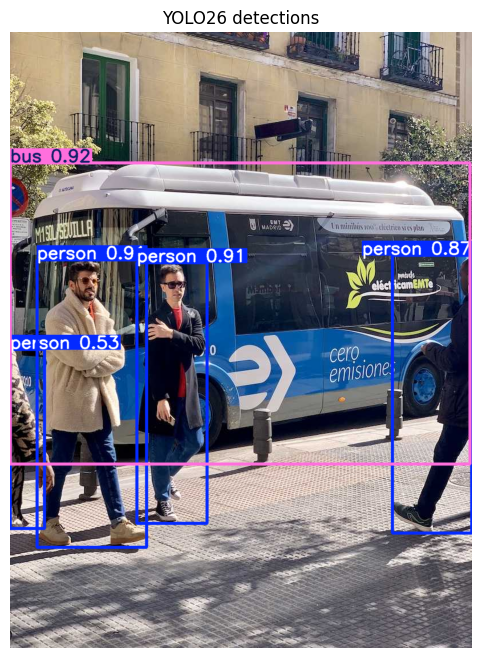

In [5]:
# result.plot() returns a BGR numpy array (OpenCV convention); matplotlib expects RGB
annotated_bgr = result.plot()
annotated_rgb = annotated_bgr[:, :, ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title('YOLO26 detections')
plt.show()

## 8. Try it yourself

Swap in your own image (a local file path or a URL) and re-run the cells above. Try lowering the `conf` threshold to see more (and less confident) detections, or raising it to see only the model's most confident predictions.

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg


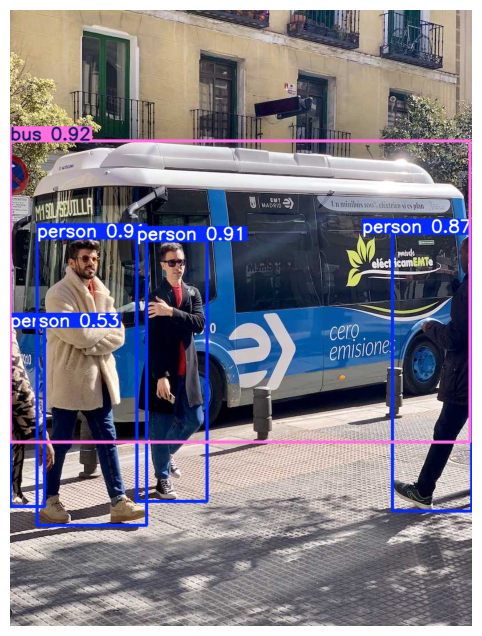

In [6]:
# Try changing the source and confidence threshold, then re-run
my_results = model.predict(source='https://ultralytics.com/images/bus.jpg', conf=0.5, verbose=False)

annotated = my_results[0].plot()[:, :, ::-1]
plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis('off')
plt.show()

## 9. From notebook to live app

That's really all `app.py` does, just applied to a continuous stream of webcam frames instead of a single image:

1. Load the model once with `@st.cache_resource` (same as our `YOLO('yolo26n.pt')` call).
2. For each incoming video frame, call `model.predict(image)` (same as `model.predict(source=...)` above).
3. Call `results[0].plot()` to draw the boxes (same as our visualization step).
4. Stream the annotated frame back to the browser.